30522
512
{'input_ids': [101, 2023, 3185, 2001, 7078, 6429, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}
[CLS] this movie was absolutely amazing! [SEP]
Shape: torch.Size([2, 9])
Attention mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])
CLS token: [CLS] (ID: 101)
SEP token: [SEP] (ID: 102)
PAD token: [PAD] (ID: 0)
Input IDs: tensor([[ 101, 2023, 3185, 2001, 7078, 6429,  999,  102]])
Decoded: [CLS] this movie was absolutely amazing! [SEP]
Исходный текст: Transformers are amazing!
Токены: ['transformers', 'are', 'amazing', '!']
IDs: [19081, 2024, 6429, 999]
Количество: 4
DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention):

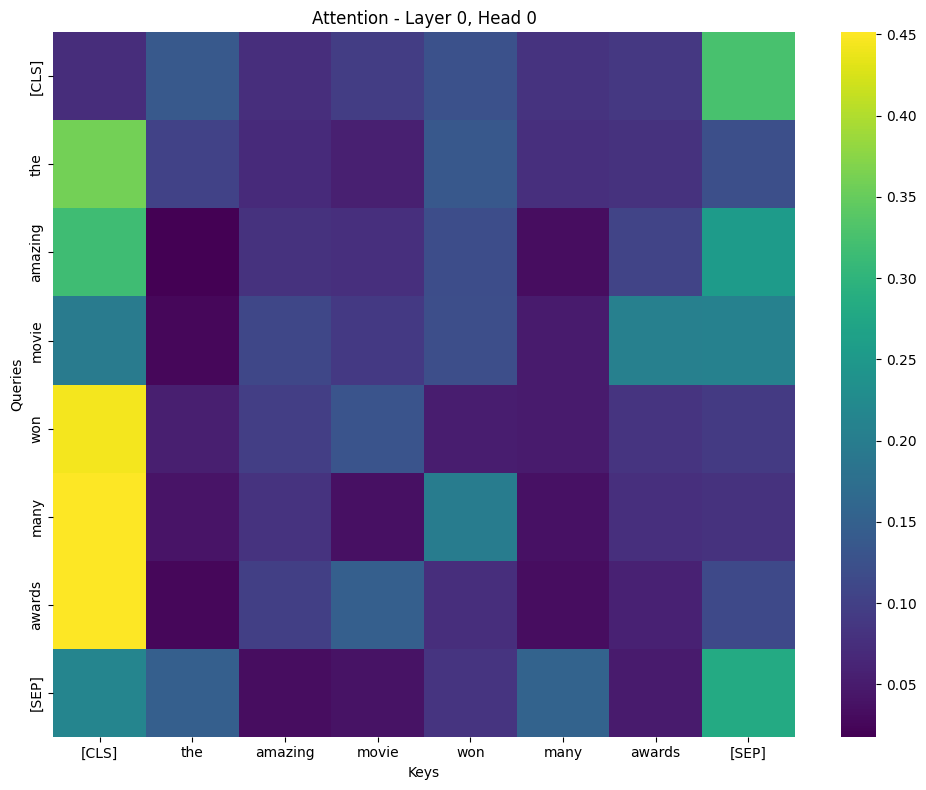

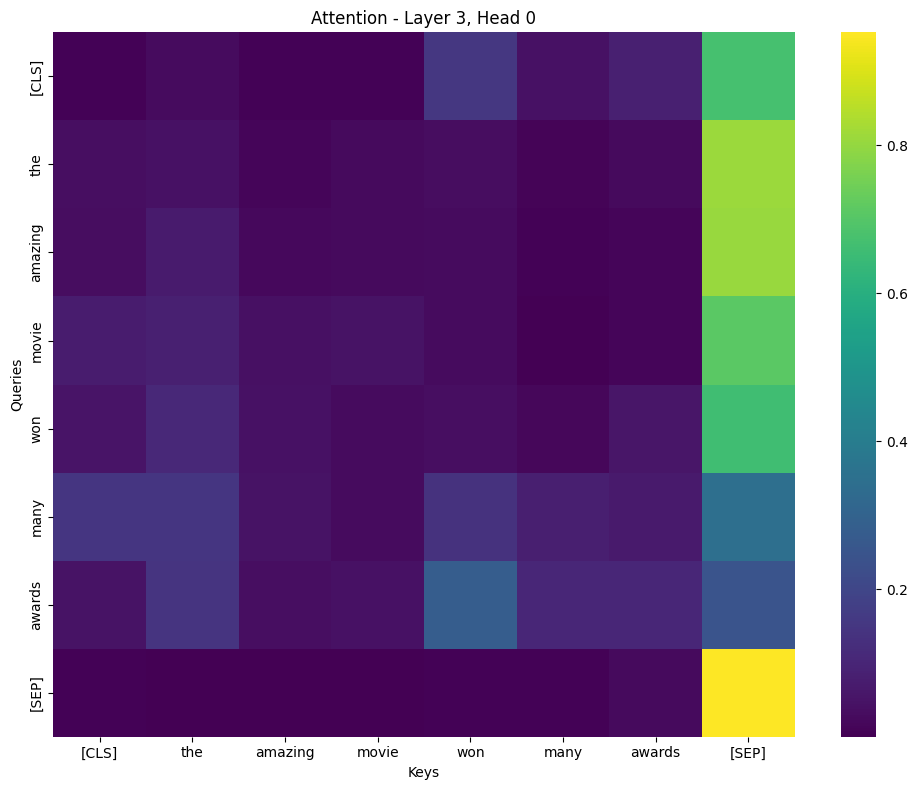

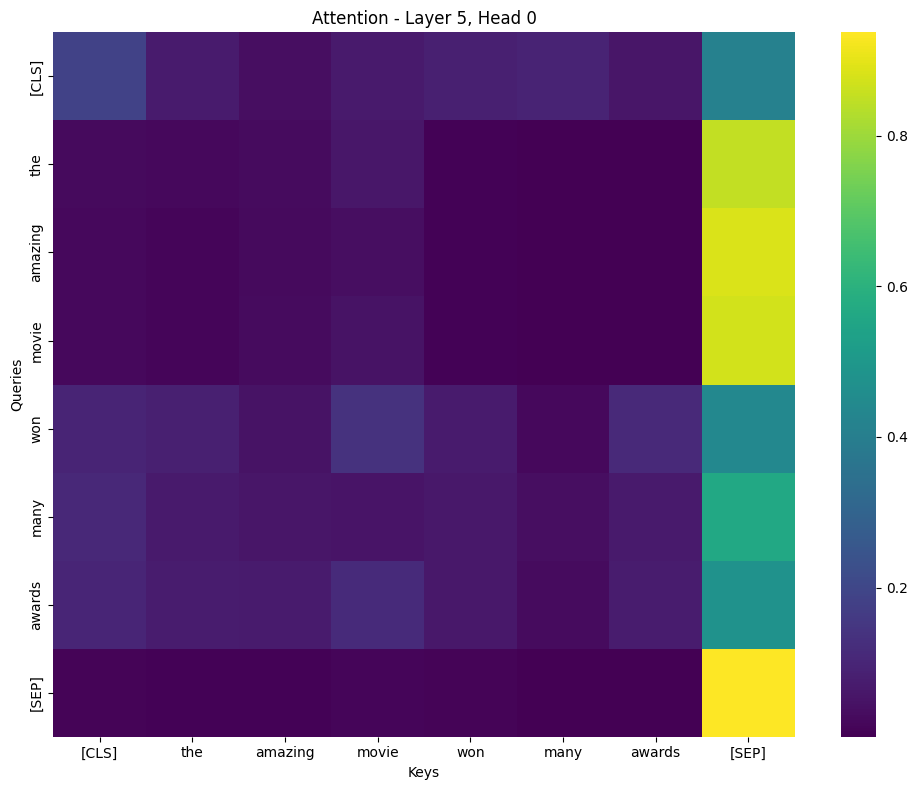

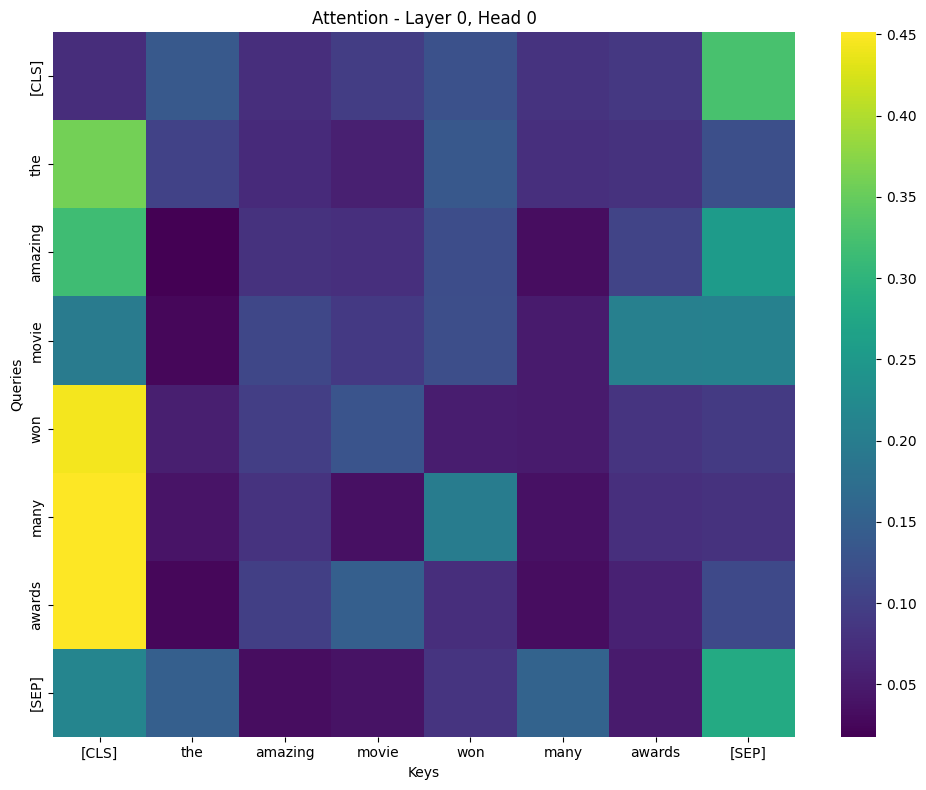

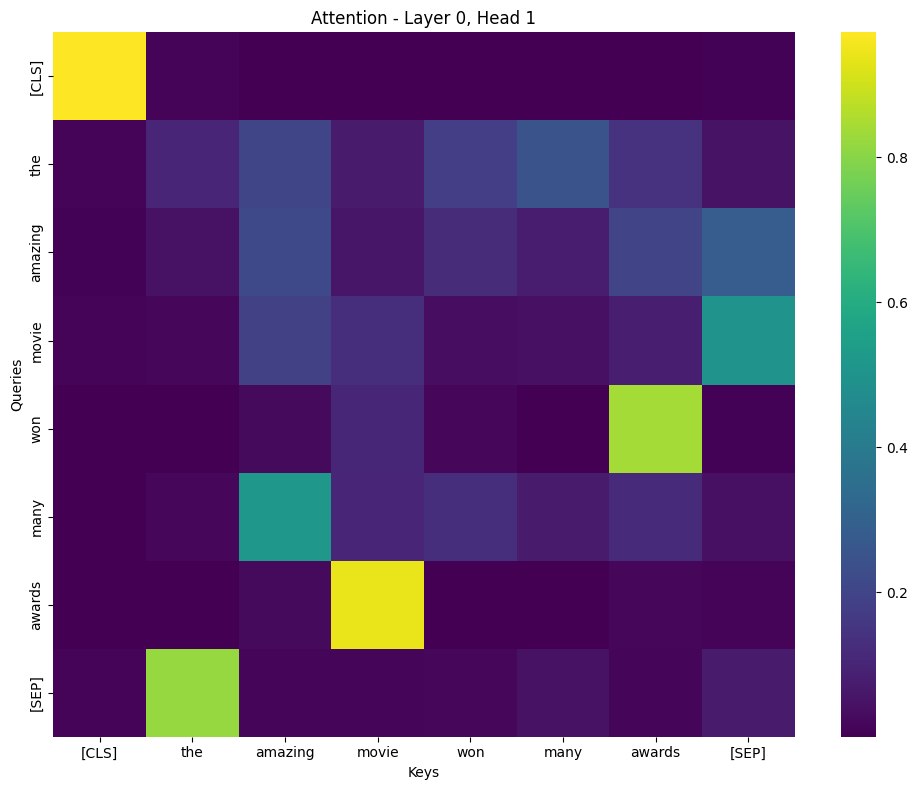

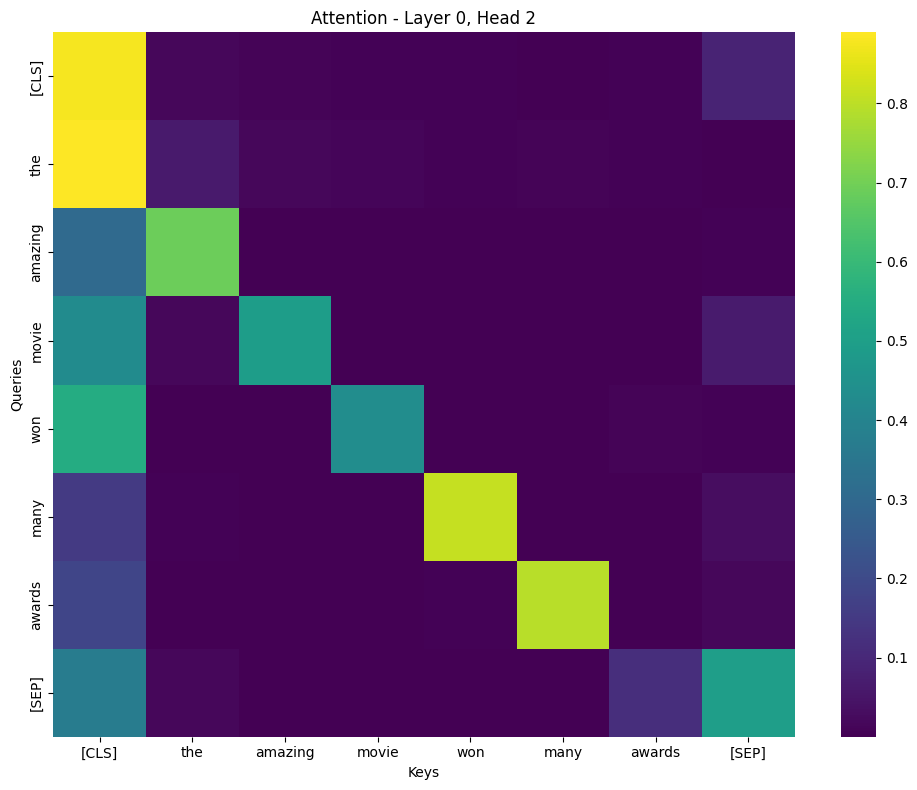

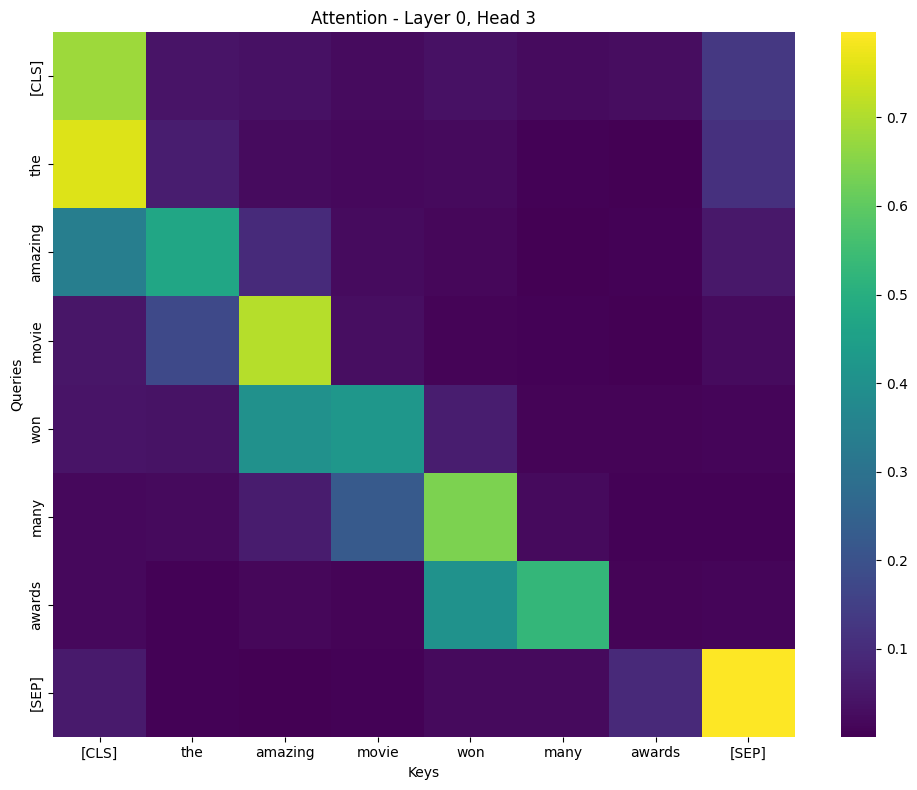

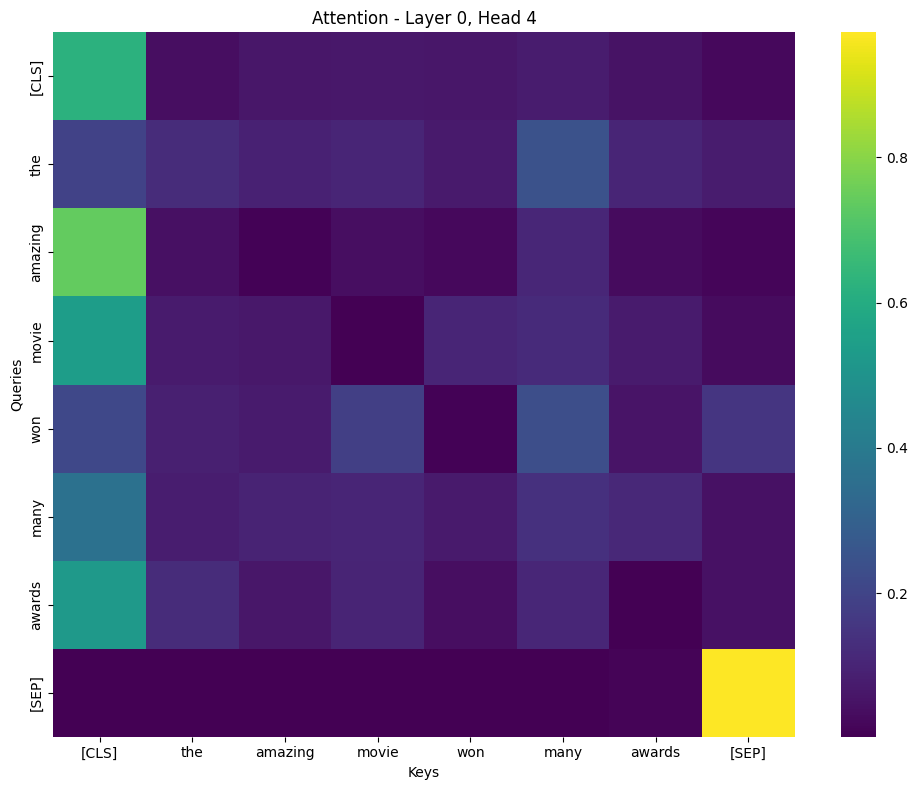

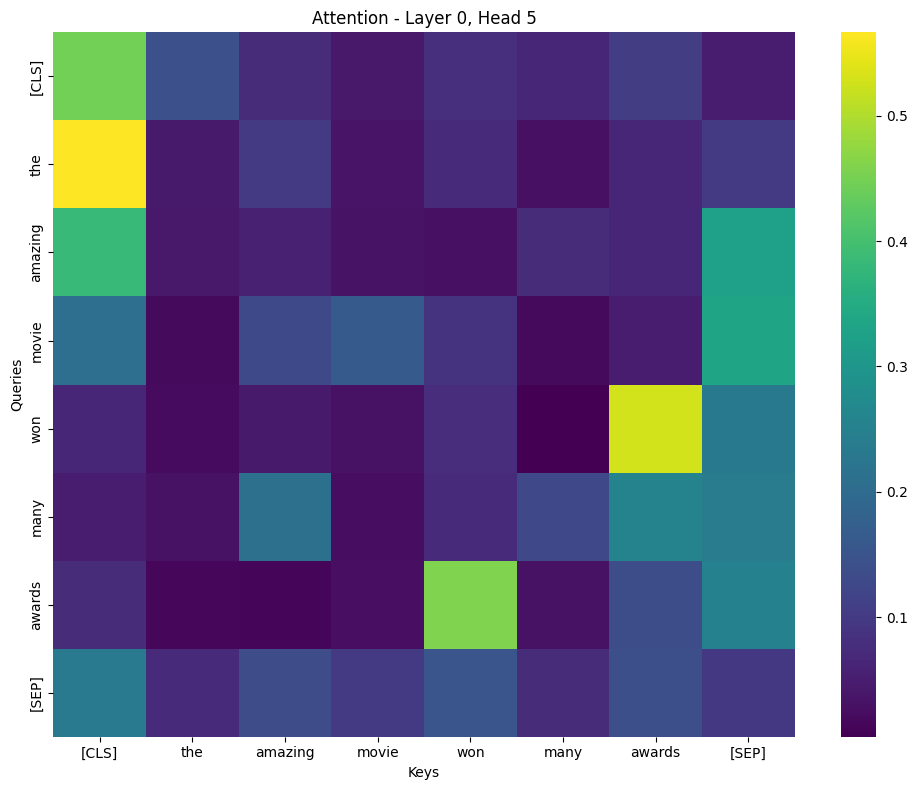

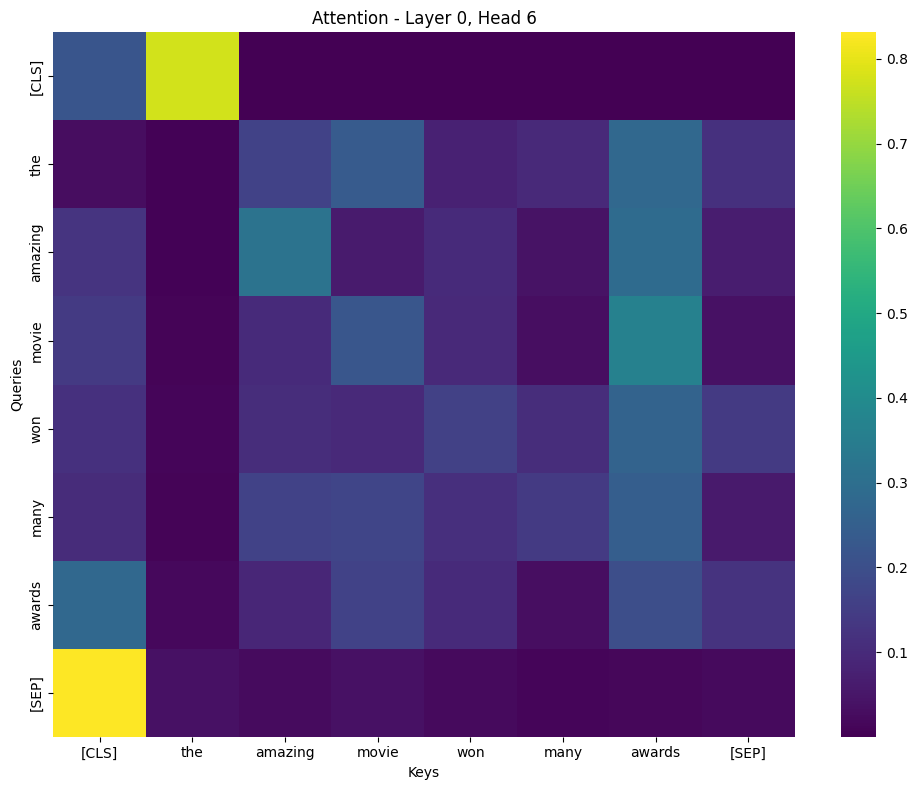

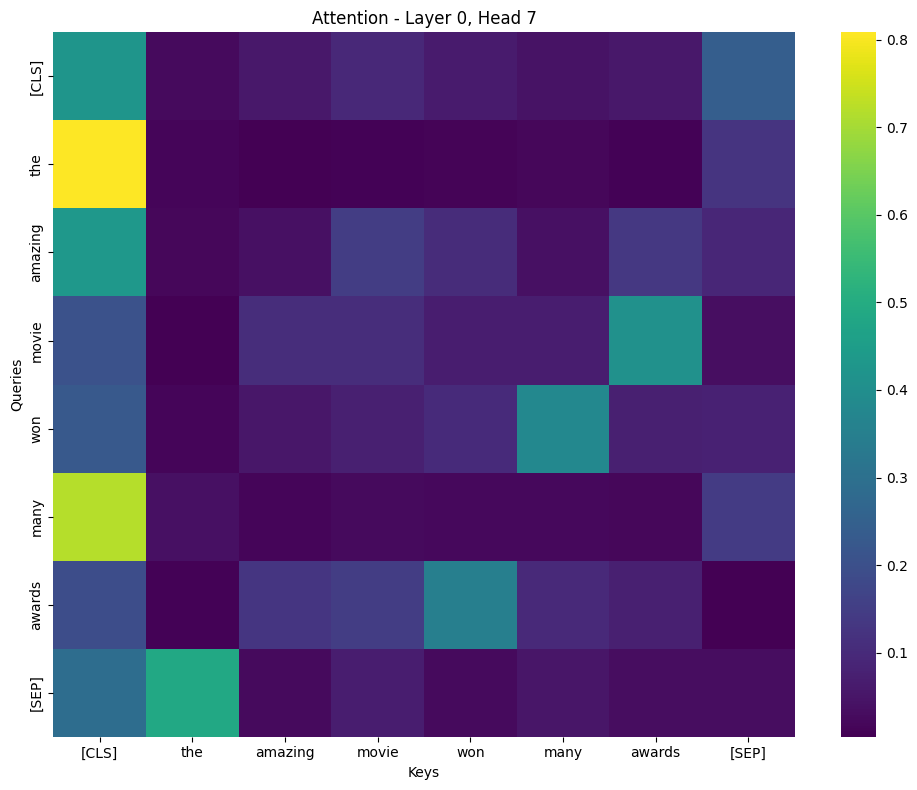

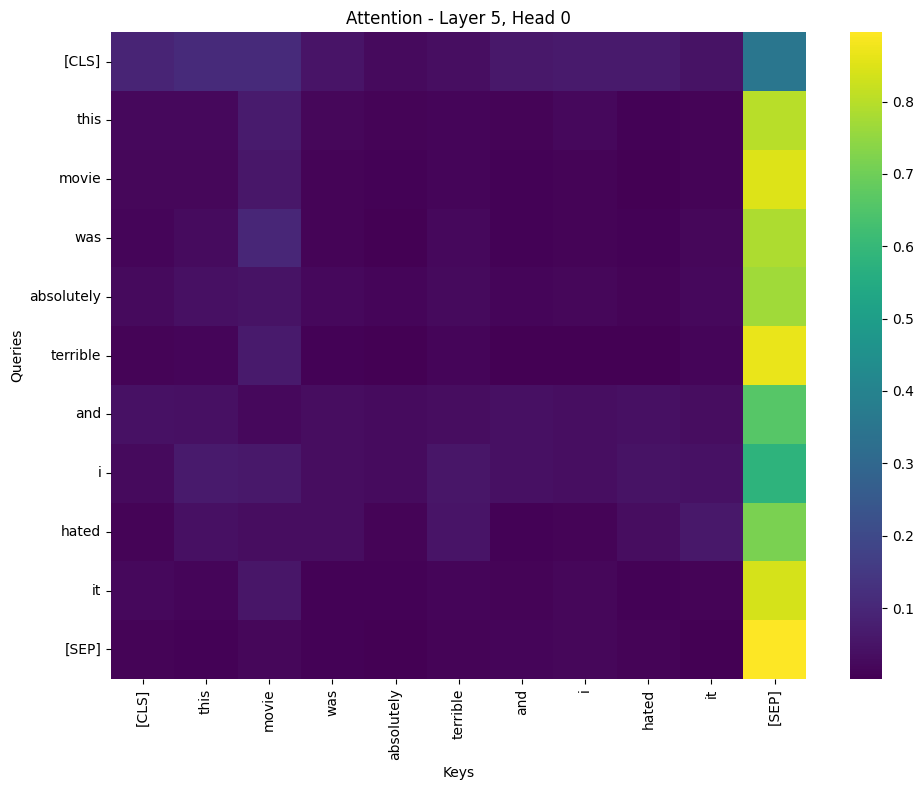

In [6]:
from transformers import AutoTokenizer
import torch

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer.vocab_size)
print(tokenizer.model_max_length)

text = "This movie was absolutely amazing!"

tokens = tokenizer(text)
print(tokens)

decoded = tokenizer.decode(tokens["input_ids"])
print(decoded)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

texts = [
    "This movie was great!",
    "Terrible movie, waste of time."
]

tokens = tokenize_texts(texts)
print(f'Shape: {tokens["input_ids"].shape}')
print(f'Attention mask:\n{tokens["attention_mask"]}')

print(f'CLS token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})')
print(f'SEP token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})')
print(f'PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})')

single = tokenizer(text, return_tensors="pt")
print(f'Input IDs: {single["input_ids"]}')
print(f'Decoded: {tokenizer.decode(single["input_ids"][0])}')

def explain_tokenization(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f'Исходный текст: {text}')
    print(f'Токены: {tokens}')
    print(f'IDs: {ids}')
    print(f'Количество: {len(tokens)}')


explain_tokenization("Transformers are amazing!", tokenizer)

from transformers import AutoModel

model_name = "distilbert-base-uncased"
model = AutoModel.from_pretrained(model_name)
model.eval()
print(model)

text = "This movie was absolutely amazing!"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

print(type(outputs))
print(outputs.last_hidden_state.shape)

cls_embedding = outputs.last_hidden_state[:, 0, :]
print(f'CLS embedding shape: {cls_embedding.shape}')
print(f'CLS embedding: {cls_embedding[0][:5]}...')

def get_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        # Токенизируем (используем функцию из Дня 1)
        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        # Получаем hidden states
        with torch.no_grad():
            outputs = model(**tokens)

        # Извлекаем CLS-токены
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    # Объединяем все батчи
    import numpy as np
    return np.vstack(all_embeddings)

texts = [
    "This movie was absolutely amazing!",
    "Terrible movie, waste of time.",
    "Pretty good, I liked it.",
    "Boring and too long."
]

embeddings = get_embeddings(texts, tokenizer, model)
print(f'Embeddings shape: {embeddings.shape}')
print(f'Ожидается: (4, 768) для DistilBERT')

from sklearn.metrics.pairwise import cosine_similarity

def similarity(text1, text2, tokenizer, model):
    emb = get_embeddings([text1, text2], tokenizer, model)
    sim = cosine_similarity(emb[0:1], emb[1:2])[0][0]
    return sim

sim1 = similarity("Great movie!", "Amazing film!", tokenizer, model)
sim2 = similarity("Great movie!", "Terrible film!", tokenizer, model)

print(f'Сходство похожих: {sim1:.3f}')
print(f'Сходство разных: {sim2:.3f}')

from transformers import AutoModel

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True  # важно!
)
model.eval()

text = "The amazing movie won many awards"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

print(type(outputs.attentions))
print(f'Количество слоёв: {len(outputs.attentions)}')
print(f'Форма attention для слоя 0: {outputs.attentions[0].shape}')

attention = outputs.attentions[0]  # первый слой
print(f'Attention shape: {attention.shape}')

# Для первого батча, первой головы
attn_single = attention[0, 0]
print(f'Single head shape: {attn_single.shape}')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_attention(tokens, attention, layer=0, head=0):
    """
    tokens: токенизированный текст
    attention: attention weights от модели
    layer: номер слоя для визуализации
    head: номер головы для визуализации
    """
    # Получаем attention матрицу
    attn = attention[layer][0, head]  # [seq_len, seq_len]

    # Получаем токены для подписей
    token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])

    # Рисуем heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn.cpu().numpy(),
        xticklabels=token_list,
        yticklabels=token_list,
        cmap='viridis',
    cbar=True
    )
    plt.title(f'Attention - Layer {layer}, Head {head}')
    plt.xlabel('Keys')
    plt.ylabel('Queries')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer}_head{head}.png')
    plt.show()

# Первый слой
visualize_attention(tokens, outputs.attentions, layer=0, head=0)

# Средний слой
visualize_attention(tokens, outputs.attentions, layer=3, head=0)

# Последний слой
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

for head in range(8):  # DistilBERT имеет 8 голов
    visualize_attention(tokens, outputs.attentions, layer=0, head=head)

text = "This movie was absolutely terrible and I hated it"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

# Визуализируйте
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

texts = [
    'Я love DataScience',
    'I hate tranny',
    'I enjoy tranning'
]

tokens = tokenize_texts(texts)

print(tokens)
print(tokens['input_ids'].shape)
print(tokens['attention_mask'])
for i in range(len(texts)):
    print(tokenizer.convert_ids_to_tokens(tokens['input_ids'][i]))

model = AutoModel.from_pretrained(model_name)
model.eval()

def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        batch_tokens = tokenize_texts(batch_texts)

        with torch.no_grad():
            outputs = model(**batch_tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

test_texts = [
    'I love transformers',
    'This course is useful',
    'Deep learning is interesting'
]

embeddings = get_cls_embeddings(test_texts)
print(embeddings.shape)


{'input_ids': tensor([[  101,  1210,  2293,  2951, 11020, 13684,   102],
        [  101,  1045,  5223, 25283,  4890,   102,     0],
        [  101,  1045,  5959, 25283,  5582,   102,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 0]])}
torch.Size([3, 7])
tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 0]])
['[CLS]', 'я', 'love', 'data', '##sc', '##ience', '[SEP]']
['[CLS]', 'i', 'hate', 'tran', '##ny', '[SEP]', '[PAD]']
['[CLS]', 'i', 'enjoy', 'tran', '##ning', '[SEP]', '[PAD]']
(3, 768)


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoTokenizer, AutoModel
import urllib3

urllib3.disable_warnings(urllib3.exceptions.NotOpenSSLWarning)

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'imdb_small.csv'
results_path = Path('baseline_results.txt')

# Load model for embeddings
model_name = "bert-base-uncased"
model = AutoModel.from_pretrained(model_name)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )


def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        batch_tokens = tokenize_texts(batch_texts)

        with torch.no_grad():
            outputs = model(**batch_tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


dataset = load_dataset('imdb')
sample_size_per_class = 250

train_df = pd.DataFrame(dataset['train'])
small_df = (
    train_df[['text', 'label']].groupby('label', group_keys=False)
    .sample(n=sample_size_per_class, random_state=42)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

small_df = small_df[['text', 'label']].dropna()
small_df['text'] = small_df['text'].astype(str)
small_df.to_csv(csv_path, index=False)

print(f'Saved dataset to: {csv_path.resolve()}')
print(small_df['label'].value_counts().sort_index())

texts = small_df['text'].tolist()
y = small_df['label'].tolist()

X = get_cls_embeddings(texts, batch_size=32)
print('Embeddings shape:', X.shape)

X = X.astype(np.float64)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


clf = LogisticRegression(
    solver="liblinear",
    C=0.1,
    max_iter=1000
)

clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

report = classification_report(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(report)
print('Macro F1:', f1)

results_text = (
    f'Dataset path: {csv_path.resolve()}\n'
    f'Samples: {len(small_df)}\n'
    f'Embeddings shape: {X.shape}\n'
    f'Train size: {len(X_train)}\n'
    f'Test size: {len(X_test)}\n'
    f'Macro F1: {f1:.4f}\n\n'
    f'{report}'
)

results_path.write_text(results_text)
print(f'Results saved to: {results_path.resolve()}')


/Users/artem/IdeaProjects/dj_vy_transform/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Saved dataset to: /Users/artem/IdeaProjects/dj_vy_transform/data/imdb_small.csv
label
0    250
1    250
Name: count, dtype: int64
Embeddings shape: (500, 768)
              precision    recall  f1-score   support

           0       0.82      0.66      0.73        50
           1       0.72      0.86      0.78        50

    accuracy                           0.76       100
   macro avg       0.77      0.76      0.76       100
weighted avg       0.77      0.76      0.76       100

Macro F1: 0.7575757575757576
Results saved to: /Users/artem/IdeaProjects/dj_vy_transform/baseline_results.txt


/Users/artem/IdeaProjects/dj_vy_transform/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/artem/IdeaProjects/dj_vy_transform/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/artem/IdeaProjects/dj_vy_transform/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
